# Case Study III: 1977 Tenerife Runway Collision

The Tenerife airport disaster[c] occurred on 27 March 1977, when two Boeing 747 passenger jets collided on the runway at Los Rodeos Airport[1] (now Tenerife North–Ciudad de La Laguna Airport) on the Spanish island of Tenerife.
 - https://en.wikipedia.org/wiki/Tenerife_airport_disaster

In [28]:
import re
import glob
import pandas as pd
import spacy
import torch
import numpy as np
from sentence_transformers import SentenceTransformer, util

###############################################################################
# 1. Runway Pattern Functions (Updated)
###############################################################################

# Updated runway regex to handle runways without side designations
RUNWAY_REGEX = re.compile(
    r'(?i)(?:runway\s+)(?P<number>\d{1,2})\s*(?:(?P<side>[LR])|(?P<sideWord>right|left))?(?=\s|$|[.,;:!])'
)

def extract_all_runway_designators(text: str) -> list:
    """
    Return all runway designators found in the text as a list.
    This version recognizes designators written either as "34R" or as "8 right" (which is normalized to "08R").
    Also handles runways without side designations like "runway 12" or "runway 30".
    """
    designators = []
    for match in RUNWAY_REGEX.finditer(text):
        number = match.group("number")
        side = match.group("side")
        side_word = match.group("sideWord")
        # Format the number to always be two digits (e.g., "8" -> "08")
        number = number.zfill(2)
        if side_word:
            side = side_word[0].upper()  # Convert "right" or "left" to "R" or "L"
        if side:
            designators.append(f"{number}{side}")
        else:
            designators.append(number)
    return designators

def is_runway_pattern(text: str) -> bool:
    """Return True if at least one runway designator is found in the text."""
    return len(extract_all_runway_designators(text)) > 0

def format_runway_code(designator: str) -> str:
    """
    Format the runway designator by prepending 'RW'.
    For example, "8R" becomes "RW8R".
    """
    return f"RW{designator}"

def find_runway_entry_node(df: pd.DataFrame, runway_designator: str) -> str | None:
    """
    Given a runway designator (e.g. "8R"), look up the CSV row where that runway
    appears as an entry. In the CSV we assume that the runway entry is indicated by:
      - Either: refName1 equals the formatted runway code and type1 equals "Entry"
      - Or: refName2 equals the formatted runway code and type2 equals "Entry"
    Returns the node 'id' of the first matching row, or None if not found.
    """
    runway_code = format_runway_code(runway_designator)  # e.g. "RW8R"
    mask_ref1 = (df['refName1'] == runway_code) & (df['type1'].str.lower() == 'entry')
    mask_ref2 = (df['refName2'] == runway_code) & (df['type2'].str.lower() == 'entry')
    match_mask = mask_ref1 | mask_ref2
    matched_rows = df[match_mask]
    if not matched_rows.empty:
        return matched_rows.iloc[0]['id']
    return None

###############################################################################
# 2. Taxiway Pattern Functions (New)
###############################################################################

# Taxiway regex to capture taxiway designations like "Charlie 1", "taxiway Charlie 2"
TAXIWAY_REGEX = re.compile(
    r'(?i)(?:taxiway\s+)?(?P<name>[A-Z][a-z]{2,})\s+(?P<number>\d+)(?=\s|$|[.,;:!])'
)

def extract_all_taxiway_designators(text: str) -> list:
    """
    Return all taxiway designators found in the text as a list.
    This recognizes patterns like "Charlie 1", "taxiway Charlie 2", etc.
    Only matches names with at least 3 characters to avoid false matches.
    Excludes runway designations and common callsigns by filtering known patterns.
    """
    designators = []
    for match in TAXIWAY_REGEX.finditer(text):
        name = match.group("name")
        number = match.group("number")
        
        # Filter out known non-taxiway patterns
        if name.lower() in ["runway", "klm", "pa", "app", "rt", "make", "end", "the"]:
            continue
            
        designators.append(f"{name} {number}")
    return designators

def is_taxiway_pattern(text: str) -> bool:
    """Return True if at least one taxiway designator is found in the text."""
    return len(extract_all_taxiway_designators(text)) > 0

###############################################################################
# 3. Node Similarity Functions for Non-Runway Destinations
###############################################################################
def build_id_embeddings(df: pd.DataFrame, model_name='sentence-transformers/all-MiniLM-L6-v2'):
    """
    Build embeddings for the 'id' column of the CSV.
    Returns a tuple (model, embeddings).
    """
    model = SentenceTransformer(model_name)
    texts = df['id'].astype(str).tolist()
    embeddings = model.encode(texts, convert_to_tensor=True)
    return model, embeddings

def find_topk_similar_nodes(query: str, df: pd.DataFrame, model, embeddings, top_k=5):
    """
    Compute top-k similarity between the query and the embedded node IDs.
    Returns a list of dictionaries with the node id and similarity score.
    """
    query_emb = model.encode(query, convert_to_tensor=True)
    cos_scores = util.cos_sim(query_emb, embeddings)[0]
    top_results = torch.topk(cos_scores, k=top_k)
    results = []
    all_ids = df['id'].tolist()
    for i, idx_tensor in enumerate(top_results.indices):
        idx = idx_tensor.item()
        score = top_results.values[i].item()
        results.append({
            "id": all_ids[idx],
            "similarity_score": float(score)
        })
    return results

###############################################################################
# 4. Main Function: Build the Meta Table from the Transcript (Updated)
###############################################################################
if __name__ == "__main__":
    # --- Load your pretrained spaCy model and add your entity ruler ---
    nlp_ner = spacy.load("./transformer/model-best")
    # Add the entity ruler (adjust the pipe position as needed)
    ruler = nlp_ner.add_pipe("entity_ruler", after="ner", config={"overwrite_ents": True})
    ruler.from_disk("entity_rulers.jsonl")
    
    # --- Load the CSV with airport nodes ---
    ICAO = 'GCXO'
    airport_nodes = f'./Airport Layouts/{ICAO}_Nodes_Def.csv'
    df = pd.read_csv(airport_nodes)
    
    # Build embeddings for non-runway similarity search on the node "id" column.
    model_id, id_embeddings = build_id_embeddings(df)
    
    # List to collect meta table rows.
    meta_rows = []
    
    # --- Process transcript files ---
    # https://www.pbs.org/wgbh/nova/planecrash/minutes.html
    test_file_paths = glob.glob('/home/yp6443/research/nlp/voice_data/test_file/*.txt')
    file_idx = 1  # adjust as needed

    with open(test_file_paths[file_idx], 'r') as file:
        for line in file:
            line_text = line.strip()
            if not line_text:
                continue
            
            # Extract the time as the first token in the line.
            time_val = line_text.split()[0]
            
            # Run your spaCy NER on the line.
            doc = nlp_ner(line_text)
            print(f"\nLine: \"{line_text}\"")
            print("Entities found:")
            for ent in doc.ents:
                print(f"  - {ent.text} : {ent.label_}")
            
            # Initialize fields (if an entity is missing, the field remains empty).
            callsign = ""
            destination_text = ""
            ac_state_list = []
            
            # Extract entity values (adjust label names as used by your model).
            for ent in doc.ents:
                if ent.label_ == "CALLSIGN":
                    callsign = ent.text
                elif ent.label_ == "DESTINATION":
                    destination_text = ent.text
                elif ent.label_ == "ACSTATE":  # or "AC_STATE" if that is your model's label
                    ac_state_list.append(ent.text)
            ac_state = ",".join(ac_state_list)
            
            # --- Determine the destination runway and final destination ---
            # First, try applying the regex to the entire line.
            designators_line = extract_all_runway_designators(line_text)
            taxiways_line = extract_all_taxiway_designators(line_text)
            
            if designators_line:
                # If found in the entire line, choose the last designator.
                chosen = designators_line[-1]
                dest_runway = chosen
                entry_node = find_runway_entry_node(df, chosen)
                if entry_node:
                    final_destination = entry_node
                else:
                    final_destination = f"No entry found for runway {chosen}"
            elif taxiways_line:
                # If taxiways are found, use the last one as destination
                chosen_taxiway = taxiways_line[-1]
                dest_runway = ""
                final_destination = chosen_taxiway
            else:
                # Otherwise, fall back to checking the DESTINATION entity.
                if destination_text and is_runway_pattern(destination_text):
                    designators = extract_all_runway_designators(destination_text)
                    chosen = designators[-1] if designators else None
                    if chosen:
                        dest_runway = chosen
                        entry_node = find_runway_entry_node(df, chosen)
                        if entry_node:
                            final_destination = entry_node
                        else:
                            final_destination = f"No entry found for runway {chosen}"
                    else:
                        final_destination = destination_text
                        dest_runway = ""
                elif destination_text and is_taxiway_pattern(destination_text):
                    taxiways = extract_all_taxiway_designators(destination_text)
                    chosen_taxiway = taxiways[-1] if taxiways else None
                    if chosen_taxiway:
                        dest_runway = ""
                        final_destination = chosen_taxiway
                    else:
                        final_destination = destination_text
                        dest_runway = ""
                else:
                    dest_runway = ""
                    # For non-runway orders, use the destination_text.
                    final_destination = destination_text
            
            # Build a meta table row.
            meta_row = {
                "callsign": callsign,
                "time": time_val,
                "ac_state": ac_state,
                "dest_runway": dest_runway,
                "destination": final_destination
            }
            meta_rows.append(meta_row)
    
    # Create and print the meta table.
    meta_df = pd.DataFrame(meta_rows, columns=["callsign", "time", "ac_state", "dest_runway", "destination"])
    
    # -----------------------
    # Post-Processing Step:
    # For each callsign, if a dest_runway is provided on any row, propagate it to all rows of that callsign.
    # Replace empty strings with NaN for proper filling.
    meta_df['dest_runway'] = meta_df['dest_runway'].replace('', np.nan)
    # For each callsign, forward-fill then backward-fill the dest_runway.
    meta_df['dest_runway'] = meta_df.groupby('callsign')['dest_runway'].transform(lambda x: x.ffill().bfill())
    # Replace NaN back with an empty string if desired.
    meta_df['dest_runway'] = meta_df['dest_runway'].fillna('')
    # -----------------------
    meta_df = meta_df[~meta_df['time'].isin(['N/A'])]
    
    print("\nFinal Meta Table:")
    print(meta_df.reset_index(drop=True))

/home/yp6443/anaconda3/envs/nlp/lib/python3.10/site-packages/spacy_transformers/layers/hf_shim.py:124: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self._model.load_state_d


Line: "1658:14.8   KLM RT    Approach KLM 4805 on the ground in Tenerife."
Entities found:
  - Approach : ACSTATE
  - KLM 4805 : CALLSIGN
  - Tenerife : DESTINATION

Line: "1658:21.5   APP       KLM 4805, roger."
Entities found:
  - KLM 4805 : CALLSIGN

Line: "1658:25.7   KLM RT    We require backtrack on runway 12 for takeoff Runway 30."
Entities found:
  - backtrack : ACSTATE
  - runway 12 : DESTINATION
  - takeoff : ACSTATE
  - Runway 30 : DESTINATION

Line: "1658:30.4   APP       Okay, KLM 4805 taxi to the holding position Runway 30. Taxi into the runway and—ah—leave runway (third) to your left."
Entities found:
  - KLM 4805 : CALLSIGN
  - taxi : ACSTATE
  - holding : ACSTATE
  - Runway 30 : DESTINATION
  - Taxi : ACSTATE
  - runway : DESTINATION
  - runway : DESTINATION

Line: "1658:47.4   KLM RT    Roger, sir, (entering) the runway at this time and the first (taxiway) we, we go off the runway again for the beginning of Runway 30."
Entities found:
  - entering : ACSTATE
  - runwa

/tmp/ipykernel_2212289/3632438295.py:255: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  meta_df['dest_runway'] = meta_df.groupby('callsign')['dest_runway'].transform(lambda x: x.ffill().bfill())


In [29]:
print("Meta Table:")
pd.set_option('display.max_rows', None)
meta_df

Meta Table:


,callsign,time,ac_state,dest_runway,destination
0,KLM 4805,1658:14.8,Approach,30,Tenerife
1,KLM 4805,1658:21.5,,30,
2,,1658:25.7,"backtrack,takeoff",30,Rwy_12_006
3,KLM 4805,1658:30.4,"taxi,holding,Taxi",30,Rwy_12_006
4,,1658:47.4,"entering,go",30,Rwy_12_006
5,,1658:55.3,taxi,30,runway
6,,1659:04.5,,30,
7,KLM 4805,1659:10.0,,30,runway
8,KLM 4805,1659:15.9,,30,
9,,1659:28.4,"Approach,turn left",30,Charlie 1


In [30]:
meta_df = meta_df[meta_df['ac_state'].str.strip() != '']

accident_time = "1706:50.00"
accident_callsign = "KLM 4805"
new_row_1 = {
        "callsign": accident_callsign,
        "time": accident_time,
        "ac_state": "collision",
        "dest_runway": "",      # Could be left empty if not available.
        "destination": ""
        }

meta_df = pd.concat([meta_df, pd.DataFrame([new_row_1])], ignore_index=True)
    
accident_callsign = "Clipper 1736"
new_row_2 = {
        "callsign": accident_callsign,
        "time": accident_time,
        "ac_state": "collision",
        "dest_runway": "",      # Could be left empty if not available.
        "destination": ""
        }
meta_df = pd.concat([meta_df, pd.DataFrame([new_row_2])], ignore_index=True)

meta_df

,callsign,time,ac_state,dest_runway,destination
0,KLM 4805,1658:14.8,Approach,30,Tenerife
1,,1658:25.7,"backtrack,takeoff",30,Rwy_12_006
2,KLM 4805,1658:30.4,"taxi,holding,Taxi",30,Rwy_12_006
3,,1658:47.4,"entering,go",30,Rwy_12_006
4,,1658:55.3,taxi,30,runway
5,,1659:28.4,"Approach,turn left",30,Charlie 1
6,,1659:32.2,taxi,30,end of the runway
7,,1702:03.6,taxi,30,runway
8,,1702:08.4,"taxi,leave",30,runway
9,,1702:49.8,pass,30,


In [31]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# === Load the airport nodes CSV ===
ICAO = 'GCXO'
airport_nodes_path = f'./Airport Layouts/{ICAO}_Nodes_Def.csv'
df_nodes = pd.read_csv(airport_nodes_path)
# (Assume df_nodes has a column called "id" that contains node names.)

# === Build embeddings for the airport nodes based on the "id" column ===
# (Assuming your build_id_embeddings function returns a model with an .encode() method and the list/array of embeddings.)
model_id, id_embeddings = build_id_embeddings(df_nodes)
# For example, id_embeddings might be a NumPy array of shape (num_nodes, embedding_dim).

# === Define a function to return the top k most similar node ids given a query string ===
def get_top_k_similar(query, model, embeddings, node_ids, k=3):
    """
    Given a query string, a model, and precomputed embeddings for node_ids,
    returns the top k most similar node ids along with their similarity scores.
    """
    # Compute embedding for the query string:
    query_embedding = model.encode(query)
    
    # Compute cosine similarity between the query and all node embeddings:
    sims = cosine_similarity([query_embedding], embeddings)[0]
    
    # Get indices for the top k similar nodes (sorted by descending similarity):
    top_indices = np.argsort(sims)[::-1][:k]
    
    # Return a list of tuples: (node_id, similarity score)
    return [(node_ids[i], sims[i]) for i in top_indices]

# === Filter the flight log for rows where the destination matches any of the target keywords ===
# Define your target keywords
keywords = ['Charlie 1', 'end of the runway']

# Create a regex pattern that matches any of these keywords.
# The pipe character '|' acts as a logical OR in regex.
pattern = '|'.join(keywords)

# Assuming your flight log DataFrame is called meta_df, create the mask:
mask = meta_df['destination'].str.contains(pattern, case=False, na=False)

# Filter the DataFrame and remove duplicate destination entries (if needed)
df_filtered = meta_df[mask].drop_duplicates(subset=['destination'])

# Get the list of node ids from the airport nodes DataFrame.
node_ids = df_nodes['id'].tolist()

# === For each filtered destination, find the top k similar node names ===
k = 5  # Adjust as needed
for idx, row in df_filtered.iterrows():
    destination_query = row['destination']
    similar_nodes = get_top_k_similar(destination_query, model_id, id_embeddings, node_ids, k=k)
    print(f"Destination '{destination_query}' top {k} similar nodes:")
    for node_name, score in similar_nodes:
        print(f"  {node_name}: {score:.4f}")
    print()

Destination 'Charlie 1' top 5 similar nodes:
  Rwy_12_001: 0.2609
  Rwy_12_006: 0.2587
  Rwy_12_005: 0.2571
  Rwy_12_002: 0.2553
  Rwy_12_003: 0.2532

Destination 'end of the runway' top 5 similar nodes:
  Rwy_12_002: 0.1695
  Rwy_12_004: 0.1671
  Rwy_12_001: 0.1577
  Rwy_12_003: 0.1560
  Rwy_12_006: 0.1553



In [32]:
from KShortestPaths_TaxiPlanGenerator import *

airports = [
    "AMS", "BOM", "CAI", "CDG", "DEL", "DME", "DXB", "FCO", "FRA", "HKG", "HND",
    "ICN", "IST", "JNB", "KABQ", "KATL", "KBDL", "KBHM", "KBNA", "KBOI", "KBOS",
    "KBTV", "KBUR", "KBWI", "KBZN", "KCHS", "KCLE", "KCLT", "KCRW", "KCVG", "KDAL",
    "KDCA", "KDEN", "KDFW", "KDSM", "KDTW", "KEWR", "KFAR", "KFLL", "KFSD", "KGYY",
    "KHPN", "KIAD", "KIAH", "KICT", "KILG", "KIND", "KISP", "KJAC", "KJAN", "KJAX",
    "KJFK", "KLAS", "KLAX", "KLEX", "KLGA", "KLGB", "KLIT", "KMCO", "KMDW", "KMEM",
    "KMHT", "KMIA", "KMKE", "KMSP", "KMSY", "KOAK", "KOKC", "KOMA", "KONT", "KORD",
    "KPBI", "KPDX", "KPHL", "KPHX", "KPIT", "KPVD", "KPWM", "KSAN", "KSAT", "KSDF",
    "KSEA", "KSFO", "KSJC", "KSLC", "KSNA", "KSTL", "KSWF", "KTEB", "KTPA", "KUL",
    "KVGT", "LHR", "MAD", "MEX", "PANC", "PEK", "PHNL", "PVG", "SIN", "SYD", "TLV",
    "TPE", "YYZ", "GCXO"
]
defFiles = [os.getcwd() + f"/Airport Layouts/{airport}_Nodes_Def.csv" for airport in airports]
linkFiles = [os.getcwd() + f"/Airport Layouts/{airport}_Nodes_Links.csv" for airport in airports]
graphs, nodePositions = loadData(defFiles, linkFiles)

graph = graphs.get(ICAO)
positions = nodePositions.get(ICAO)
NUM_PATHS = 1

# KLM 4805
start11 = 'Rwy_12_001'
end11 = 'Rwy_12_006'
start12 = 'Rwy_12_006'
end12 = 'Rwy_12_005'
# Clipper 1736
start21 = 'Txy_C0_001'
end21 = 'Rwy_12_001'
start22 = 'Rwy_12_001'
end22 = 'Rwy_12_005'
# Generate paths for KLM 4805 (two segments)
path11 = aStarMultiple(graph, start11, end11, positions, k=NUM_PATHS)
path12 = aStarMultiple(graph, start12, end12, positions, k=NUM_PATHS)

# Append node names for path 1 and calculate total distance
path1_nodes = []
path1_total_distance = 0.0

# Process path11 (first segment)
for path, distance in path11:
    path1_nodes.extend(path)
    path1_total_distance += distance

# Process path12 (second segment) - remove duplicate node if it exists
for path, distance in path12:
    # Remove the first node if it's the same as the last node of path11
    if path1_nodes and path and path[0] == path1_nodes[-1]:
        path1_nodes.extend(path[1:])  # Skip the first node to avoid duplication
    else:
        path1_nodes.extend(path)
    path1_total_distance += distance

# Create the combined path1 with total distance
path1 = [(path1_nodes, path1_total_distance)]

# Generate paths for Clipper 1736 (two segments)
path21 = aStarMultiple(graph, start21, end21, positions, k=NUM_PATHS)
path22 = aStarMultiple(graph, start22, end22, positions, k=NUM_PATHS)

# Append node names for path 2 and calculate total distance
path2_nodes = []
path2_total_distance = 0.0

# Process path21 (first segment)
for path, distance in path21:
    path2_nodes.extend(path)
    path2_total_distance += distance

# Process path22 (second segment) - remove duplicate node if it exists
for path, distance in path22:
    # Remove the first node if it's the same as the last node of path21
    if path2_nodes and path and path[0] == path2_nodes[-1]:
        path2_nodes.extend(path[1:])  # Skip the first node to avoid duplication
    else:
        path2_nodes.extend(path)
    path2_total_distance += distance

# Create the combined path2 with total distance
path2 = [(path2_nodes, path2_total_distance)]

print('KLM 4805 Possible Paths:')
for i, (path, distance) in enumerate(path1, start=1):
    print(f"Path {i}: {path}, Total Distance: {distance:.2f} mile")

print('Clipper 1736 Possible Paths:')
for i, (path, distance) in enumerate(path2, start=1):
    print(f"Path {i}: {path}, Total Distance: {distance:.2f} mile")


KLM 4805 Possible Paths:
Path 1: ['Rwy_12_001', 'Rwy_12_002', 'Rwy_12_003', 'Rwy_12_004', 'Rwy_12_005', 'Rwy_12_006', 'Rwy_12_005'], Total Distance: 2.88 mile
Clipper 1736 Possible Paths:
Path 1: ['Txy_C0_001', 'Txy_C0_002', 'Rwy_12_001', 'Rwy_12_002', 'Rwy_12_003', 'Rwy_12_004', 'Rwy_12_005'], Total Distance: 1.32 mile


In [33]:
# Precise timing animation functions
import math
import io
import os
import imageio
import matplotlib.pyplot as plt
import pandas as pd

def calculate_segment_distances(path, nodePositions):
    """Calculate distances for each segment in the path"""
    distances = []
    for i in range(len(path) - 1):
        pos1 = nodePositions[path[i]]
        pos2 = nodePositions[path[i+1]]
        # Calculate distance in miles (assuming lat/lon are in degrees)
        # Rough conversion: 1 degree ≈ 69 miles
        distance_miles = math.sqrt((pos2[0] - pos1[0])**2 + (pos2[1] - pos1[1])**2) * 69
        distances.append(distance_miles)
    return distances

def get_position_along_path_precise_timing(path, nodePositions, segment_times, t):
    """
    Given a list of node IDs in 'path', returns the interpolated position (lat, lon)
    at simulation time t (in seconds), based on precise timing for each segment.
    
    Args:
        path: List of node IDs
        nodePositions: Dictionary of node positions
        segment_times: List of time durations for each segment (seconds)
        t: Time in seconds
    """
    # Ensure we have the right number of segment times
    if len(segment_times) != len(path) - 1:
        raise ValueError(f"segment_times must have {len(path) - 1} elements, got {len(segment_times)}")

    # Compute cumulative times along the path segments
    cum_times = [0]
    for i in range(len(segment_times)):
        cum_times.append(cum_times[-1] + segment_times[i])
    
    total_time = cum_times[-1]

    # If we've passed the total time, return the final node position.
    if t >= total_time:
        return nodePositions[path[-1]], total_time

    # Find the segment where the current time lies.
    for i in range(1, len(cum_times)):
        if t < cum_times[i]:
            pos1 = nodePositions[path[i-1]]
            pos2 = nodePositions[path[i]]
            seg_progress = (t - cum_times[i-1]) / (cum_times[i] - cum_times[i-1])
            lat = pos1[0] + seg_progress * (pos2[0] - pos1[0])
            lon = pos1[1] + seg_progress * (pos2[1] - pos1[1])
            return (lat, lon), total_time

def animate_precise_timing(linksDf, nodePositions, path1, segment_times1, path2, segment_times2, airport_name, output_filename, collision_time, xlims=None, ylims=None, time_lag=0, save_frames_dir=None):
    """
    Animates two aircraft with precise timing control and optional time lag.
    """
    
    # Calculate total times
    total_time1 = sum(segment_times1)
    total_time2 = sum(segment_times2)
    overall_total_time = max(total_time1, total_time2 + time_lag)
    
    print(f"Aircraft 1 total time: {total_time1} seconds")
    print(f"Aircraft 2 total time: {total_time2} seconds")
    print(f"Aircraft 2 starts at: {time_lag} seconds")
    print(f"Collision time: {collision_time} seconds")

    frames = []
    for t in range(overall_total_time + 1):
        # Calculate positions for both aircraft
        pos1, _ = get_position_along_path_precise_timing(path1, nodePositions, segment_times1, t)
        
        # Aircraft 2 starts after time_lag
        if t >= time_lag:
            pos2, _ = get_position_along_path_precise_timing(path2, nodePositions, segment_times2, t - time_lag)
        else:
            # Aircraft 2 hasn't started yet, use starting position
            pos2 = nodePositions[path2[0]]
        
        # Create figure
        fig, ax = plt.subplots(figsize=(10, 10))
        
        # Set custom zoom (if provided)
        if xlims is not None:
            ax.set_xlim(xlims)
        if ylims is not None:
            ax.set_ylim(ylims)
            
        # Draw background
        for _, row in linksDf.iterrows():
            try:
                n1_lon = float(row['n1.lon'])
                n1_lat = float(row['n1.lat'])
                n2_lon = float(row['n2.lon'])
                n2_lat = float(row['n2.lat'])
                ax.plot([n1_lon, n2_lon], [n1_lat, n2_lat], color='gray', linestyle='-', linewidth=0.5)
            except:
                continue

        # Draw nodes
        for nodeId, (lat, lon) in nodePositions.items():
            ax.scatter(lon, lat, color='blue', s=20, zorder=2)
            ax.text(lon, lat, nodeId, fontsize=8, ha='right', va='bottom')
        
        # Plot the planned paths
        path1_lats = [nodePositions[node][0] for node in path1]
        path1_lons = [nodePositions[node][1] for node in path1]
        ax.plot(path1_lons, path1_lats, color='red', linestyle='--', linewidth=2, label='KLM 4805')
        
        # Only plot path2 if aircraft 2 has started
        if t >= time_lag:
            path2_lats = [nodePositions[node][0] for node in path2]
            path2_lons = [nodePositions[node][1] for node in path2]
            ax.plot(path2_lons, path2_lats, color='green', linestyle='--', linewidth=2, label='Clipper 1736')
        
        # Plot current positions
        ax.scatter(pos1[1], pos1[0], color='red', s=100, zorder=3, label='KLM 4805' if t==0 else "")
        
        # Only plot aircraft 2 if it has started
        if t >= time_lag:
            ax.scatter(pos2[1], pos2[0], color='green', s=100, zorder=3, label='Clipper 1736' if t==time_lag else "")
        else:
            # Show aircraft 2 at starting position but with different styling
            ax.scatter(pos2[1], pos2[0], color='lightgray', s=50, zorder=2, alpha=0.5, label='Clipper 1736 (waiting)' if t==0 else "")
        
        # Check for collision
        collision_detected = False
        if t == collision_time:
            # Show collision warning
            ax.scatter(pos1[1], pos1[0], color='yellow', s=200, marker='*', zorder=4, label='COLLISION!' if t==collision_time else "")
            collision_detected = True
        
        # Display simulation time and status
        status_text = f"t = {t} s"
        if t < time_lag:
            status_text += f"\\nAircraft 2 starts in {time_lag - t} s"
        elif t == time_lag:
            status_text += f"\\nAircraft 2 starts now!"
        elif collision_detected:
            status_text += f"\\nCOLLISION!"
        elif t > collision_time:
            status_text += f"\\nPost-collision"
        
        ax.text(0.05, 0.05, status_text, transform=ax.transAxes,
                fontsize=12, color='black', verticalalignment='bottom',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        
        # Add legend
        ax.legend(loc='upper right')
        
        if save_frames_dir:
            # Save each frame as a PNG file.
            frame_filename = os.path.join(save_frames_dir, f'{airport_name}_frame_{t:04d}.png')
            plt.savefig(frame_filename, format='png', dpi=300)
            # print(f"Saved frame: {frame_filename}")
        else:
            # Save the frame to an in-memory buffer.
            buf = io.BytesIO()
            plt.savefig(buf, format='png', dpi=150)
            buf.seek(0)
            image = imageio.imread(buf)
            frames.append(image)
        
        plt.close(fig)
    
    if not save_frames_dir:
        # Save all frames as an animated GIF if not saving individual images.
        imageio.mimsave(output_filename, frames, duration=0.1)
        print(f"Animation saved to {output_filename}")
    else:
        print(f"Individual frames saved to {save_frames_dir}")


In [34]:
# FINAL FIX: Use the correct coordinates and timing
print("=== FINAL FIX: CORRECT COORDINATES AND TIMING ===")

# Get the actual paths
path_klm = path1[0][0]  # KLM 4805 path
path_clipper = path2[0][0]  # Clipper 1736 path

print(f"KLM 4805 path: {path_klm}")
print(f"KLM segments: {len(path_klm) - 1}")
print(f"Clipper 1736 path: {path_clipper}")
print(f"Clipper segments: {len(path_clipper) - 1}")

# Use the corrected segment times we calculated
klm_segment_times = [76, 53, 49, 35, 190, 54]  # Total: 457 seconds
# First 3 segments: 76 + 53 + 49 = 178 seconds
# Segments 4,5: 35 + 190 = 225 seconds  
# Last segment: 54 seconds

clipper_segment_times = [121, 57, 96, 67, 62, 54]  # Total: 457 seconds
# First 2 segments: 121 + 57 = 178 seconds
# Segments 3,4,5: 96 + 67 + 62 = 225 seconds  
# Last segment: 54 seconds

print(f"\nKLM segment times: {klm_segment_times} (length: {len(klm_segment_times)})")
print(f"Clipper segment times: {clipper_segment_times} (length: {len(clipper_segment_times)})")

# Verify timing
klm_total_time = sum(klm_segment_times)
clipper_total_time = sum(clipper_segment_times)
clipper_start_time = 0  # Both aircraft start at the same time now

print(f"\nKLM total time: {klm_total_time} seconds")
print(f"Clipper total time: {clipper_total_time} seconds")
print(f"Both aircraft start at: t=0 seconds")

# Collision occurs when both aircraft reach the same point
collision_time = max(klm_total_time, clipper_total_time)

print(f"Collision time: {collision_time} seconds")

# Use the correct nodePositions from the path generation system
# This is the key fix - use 'positions' not 'nodePositions'
correct_nodePositions = positions  # This comes from the path generation code

print(f"\nUsing nodePositions with {len(correct_nodePositions)} nodes")
print("Sample nodes:")
for i, (node, pos) in enumerate(list(correct_nodePositions.items())[:5]):
    print(f"  {node}: {pos}")

# Load the links data for the animation
linksDf = pd.read_csv(f'./Airport Layouts/{ICAO}_Nodes_Links.csv')

# Create the animation with the correct timing and nodePositions
animate_precise_timing(
    linksDf=linksDf,
    nodePositions=correct_nodePositions,
    path1=path_klm,
    segment_times1=klm_segment_times,
    path2=path_clipper,
    segment_times2=clipper_segment_times,
    airport_name=ICAO,
    output_filename='case-study-3.gif',
    collision_time=collision_time,
    xlims=None,
    ylims=None,
    time_lag=clipper_start_time,
    save_frames_dir='frames'
)


=== FINAL FIX: CORRECT COORDINATES AND TIMING ===
KLM 4805 path: ['Rwy_12_001', 'Rwy_12_002', 'Rwy_12_003', 'Rwy_12_004', 'Rwy_12_005', 'Rwy_12_006', 'Rwy_12_005']
KLM segments: 6
Clipper 1736 path: ['Txy_C0_001', 'Txy_C0_002', 'Rwy_12_001', 'Rwy_12_002', 'Rwy_12_003', 'Rwy_12_004', 'Rwy_12_005']
Clipper segments: 6

KLM segment times: [76, 53, 49, 35, 190, 54] (length: 6)
Clipper segment times: [121, 57, 96, 67, 62, 54] (length: 6)

KLM total time: 457 seconds
Clipper total time: 457 seconds
Both aircraft start at: t=0 seconds
Collision time: 457 seconds

Using nodePositions with 19 nodes
Sample nodes:
  Rwy_12_001: (28.487889, -16.357273)
  Rwy_12_002: (28.485553, -16.350255)
  Rwy_12_003: (28.483932, -16.34536)
  Rwy_12_004: (28.482443, -16.340874)
  Rwy_12_005: (28.481667, -16.338548)
Aircraft 1 total time: 457 seconds
Aircraft 2 total time: 457 seconds
Aircraft 2 starts at: 0 seconds
Collision time: 457 seconds
Individual frames saved to frames


# Risk Formulation

In [35]:
import math
import re
from typing import List, Tuple, Dict, Optional

import numpy as np
from scipy.stats import lognorm
from scipy.integrate import quad

# -------------------------------
# Core distributions / utilities
# -------------------------------

def travel_time_pdf(t: float, mu_star: float, sigma_star: float) -> float:
    """
    PDF of Lognormal(mu_star, sigma_star^2) for travel time Gamma.
    (mu_star, sigma_star) are the *log-space* parameters of Gamma.
    """
    if t <= 0:
        return 0.0
    return lognorm.pdf(t, s=sigma_star, scale=np.exp(mu_star))

def fenton_wilkinson_params(M: float, V: float) -> Tuple[float, float]:
    """
    Given mean M and variance V of a positive r.v., return
    (mu_star, sigma_star) for a Lognormal approx: Gamma ~ LogN(mu_star, sigma_star^2).
    """
    if M <= 0:
        raise ValueError("Mean M must be positive.")
    sigma2_star = np.log(1.0 + V / (M**2))
    sigma_star = float(np.sqrt(max(sigma2_star, 0.0)))
    mu_star = float(np.log(M) - 0.5 * sigma2_star)
    return mu_star, sigma_star

def moments_tau_from_speed_lognormal(d: float, mu_v: float, sigma_v: float) -> Tuple[float, float]:
    """
    For a link with distance d and speed v ~ LogN(mu_v, sigma_v^2),
    the link time tau = d / v has:
      E[tau] = d * exp(-mu_v + 0.5*sigma_v^2)
      Var[tau] = d^2 * exp(-2*mu_v + sigma_v^2) * (exp(sigma_v^2) - 1)
    """
    E_tau = d * math.exp(-mu_v + 0.5 * sigma_v**2)
    Var_tau = (d**2) * math.exp(-2*mu_v + sigma_v**2) * (math.exp(sigma_v**2) - 1.0)
    return E_tau, Var_tau

def compute_total_moments_links(links: List[Tuple[float, float, float]]) -> Tuple[float, float]:
    """
    Sum of moments across links for a route to the node.
    Each link is (distance, mu_v, sigma_v) with mu_v, sigma_v = lognormal speed params (natural log).
    Independence across links is assumed (FW).
    Returns (M, V) for total travel time Gamma.
    """
    M, V = 0.0, 0.0
    for (d, mu_v, sigma_v) in links:
        m, v = moments_tau_from_speed_lognormal(d, mu_v, sigma_v)
        M += m
        V += v  # if you have covariances, add them here consistently
    return M, V

def f_delta_zero_lognormals(mu1: float, s1: float, mu2: float, s2: float) -> float:
    """
    Compute f_Δ(0) = ∫_0^∞ f1(t) f2(t) dt for two lognormals LogN(mu1,s1^2), LogN(mu2,s2^2).
    Numerically stable via change of variables t = exp(u), dt = exp(u) du, u in (-inf, inf).
    """
    const = 1.0 / (2.0 * math.pi * s1 * s2)  # from product of normalizing constants
    def integrand_u(u):
        # For lognormal, f(t) = 1/(t s sqrt(2π)) * exp(-(ln t - mu)^2 / (2 s^2))
        # Product f1*f2 * dt = [const] * exp( -((u-mu1)^2/(2 s1^2) + (u-mu2)^2/(2 s2^2)) ) * exp(u - 2u)
        # BUT careful: f1*f2 has 1/t^2; dt = e^u du; so net factor e^u / e^{2u} = e^{-u}
        # Derive explicitly to avoid mistakes:
        # f1 = 1/(e^u s1 sqrt(2π)) * exp(-(u-mu1)^2/(2 s1^2))
        # f2 = 1/(e^u s2 sqrt(2π)) * exp(-(u-mu2)^2/(2 s2^2))
        # f1*f2 = 1/(e^{2u} 2π s1 s2) * exp( -[...] )
        # dt = e^u du  => (f1*f2) dt = const * exp( -[...] ) * e^{-u}
        expo = -((u - mu1)**2) / (2.0 * s1**2) - ((u - mu2)**2) / (2.0 * s2**2)
        return math.exp(expo - u)

    # Integrate over u in R; truncate to reasonable bounds using normal tails around both mus
    # Use a heuristic window covering +/- 8 std around both centers
    u_center = 0.5 * (mu1 + mu2)
    u_spread = 8.0 * max(s1, s2) + 4.0  # a little extra margin
    a, b = u_center - u_spread, u_center + u_spread

    val, err = quad(lambda u: const * integrand_u(u), a, b, epsabs=1e-10, epsrel=1e-8, limit=200)
    return max(val, 0.0)  # numerical safeguard

def expected_inv_speed(mu_v: float, sigma_v: float) -> float:
    """
    For v ~ LogN(mu_v, sigma_v^2), E[1/v] = exp(-mu_v + 0.5*sigma_v^2).
    """
    return math.exp(-mu_v + 0.5 * sigma_v**2)

# ----------------------------------------------
# Node-level risks from two cumulative link sets
# ----------------------------------------------

def node_overlap_density_fdelta0(links1: List[Tuple[float,float,float]],
                                 links2: List[Tuple[float,float,float]]) -> Tuple[float, Tuple[float,float], Tuple[float,float]]:
    """
    Compute f_Δ(0) using FW approximations for the two routes' total times.
    Returns f_delta0 and the (mu*,sigma*) pairs for each route.
    """
    # FW parameters for Gamma_1
    M1, V1 = compute_total_moments_links(links1)
    mu1_star, s1_star = fenton_wilkinson_params(M1, V1)

    # FW parameters for Gamma_2
    M2, V2 = compute_total_moments_links(links2)
    mu2_star, s2_star = fenton_wilkinson_params(M2, V2)

    f0 = f_delta_zero_lognormals(mu1_star, s1_star, mu2_star, s2_star)
    return f0, (mu1_star, s1_star), (mu2_star, s2_star)

def pn_probability_small_window(f_delta0: float, epsilon: float) -> float:
    """
    P_PN^{(ε)} ≈ 2 ε f_Δ(0)
    """
    return max(0.0, 2.0 * epsilon * f_delta0)

def fw_collision_probability(f_delta0: float,
                             rc: float,
                             mu_v1_star: float, s_v1_star: float,
                             mu_v2_star: float, s_v2_star: float,
                             how: str = "average") -> float:
    """
    P_FW(x_c) ≈ 2 r_c E[1/v_*] f_Δ(0)
    Choose how to estimate E[1/v_*]:
      - "aircraft1": use incoming-speed params from aircraft 1
      - "aircraft2": use incoming-speed params from aircraft 2
      - "average" : average the two aircrafts' inverse-speed expectations (default)
    """
    e1 = expected_inv_speed(mu_v1_star, s_v1_star)
    e2 = expected_inv_speed(mu_v2_star, s_v2_star)
    if how == "aircraft1":
        e_inv = e1
    elif how == "aircraft2":
        e_inv = e2
    else:
        e_inv = 0.5 * (e1 + e2)
    return max(0.0, 2.0 * rc * e_inv * f_delta0)

# --------------------------------------------------------------------
# Helpers for paths / links (expects lognormal SPEED params for speed)
# --------------------------------------------------------------------

def get_cumulative_links(path: List[str],
                         target: str,
                         link_dict: Dict[Tuple[str,str], Tuple[float,float,float]],
                         default_link: Optional[Tuple[float,float,float]] = None) -> Optional[List[Tuple[float,float,float]]]:
    """
    Return cumulative list of (distance, mu_v, sigma_v) from path start up to 'target'.
    Node keys are case-insensitive; undirected lookup (i->i+1) or (i+1->i).
    """
    norm_path = [p.strip().upper() for p in path]
    target_u = target.strip().upper()
    if target_u not in norm_path:
        return None

    upto = norm_path.index(target_u)
    if upto == 0:
        return []

    links = []
    for i in range(upto):
        a, b = norm_path[i], norm_path[i+1]
        
        # Try to find the link in the dictionary with case-insensitive lookup
        found_link = None
        for (key_a, key_b), link_data in link_dict.items():
            if (key_a.upper() == a and key_b.upper() == b) or (key_a.upper() == b and key_b.upper() == a):
                found_link = link_data
                break
        
        if found_link is not None:
            links.append(found_link)
        elif default_link is not None:
            links.append(default_link)
        else:
            raise KeyError(f"Missing link parameters for ({a}, {b}) or ({b}, {a}).")
    return links

def intersection_of_lists(list1: List[str], list2: List[str]) -> List[str]:
    """Ordered intersection by list1 order."""
    s2 = set(list2)
    return [x for x in list1 if x in s2]

# -------------------------------------------------------
# Example: per-node risk from two paths up to each node
# -------------------------------------------------------

def risks_for_intersection_nodes(
    path1: List[str],
    path2: List[str],
    link_dict: Dict[Tuple[str,str], Tuple[float,float,float]],
    rc: float,
    epsilon: float,
    e_inv_mode: str = "average"
):
    """
    For each common node between path1 and path2, compute:
      - f_delta0,
      - P_PN^{(ε)} ≈ 2 ε f_delta0,
      - P_FW ≈ 2 r_c E[1/v_*] f_delta0 (E[1/v_*] via incoming link(s)).
    Assumes link_dict stores (distance, mu_v, sigma_v) with mu_v, sigma_v in log-space.
    """
    results = []
    commons = intersection_of_lists(path1, path2)
    for node in commons:
        links1 = get_cumulative_links(path1, node, link_dict)
        links2 = get_cumulative_links(path2, node, link_dict)
        if not links1 or not links2:
            # need at least one link each to define Gamma up to node
            continue

        # 1) Overlap density from FW
        f0, (mu1_star, s1_star), (mu2_star, s2_star) = node_overlap_density_fdelta0(links1, links2)

        # 2) PN probability
        Ppn = pn_probability_small_window(f0, epsilon)

        # 3) FW probability: choose incoming link for "local" speed; last link toward the node
        mu_v1_in, s_v1_in = links1[-1][1], links1[-1][2]
        mu_v2_in, s_v2_in = links2[-1][1], links2[-1][2]
        Pfw = fw_collision_probability(f0, rc, mu_v1_in, s_v1_in, mu_v2_in, s_v2_in, how=e_inv_mode)

        results.append({
            "node": node,
            "mu1_star": mu1_star, "sigma1_star": s1_star,
            "mu2_star": mu2_star, "sigma2_star": s2_star,
            "f_delta0": f0,
            "P_PN_epsilon": Ppn,
            "P_FW": Pfw
        })
    return results

# -------------------------------------------------------
# (Optional) helpers if your speed params are *not* in log-space
# -------------------------------------------------------

def speed_meanstd_to_lognormal(mu_lin: float, sd_lin: float) -> Tuple[float, float]:
    """
    Convert linear-space (mean, std) of speed to lognormal (mu, sigma) of ln(speed).
    """
    if mu_lin <= 0:
        raise ValueError("Speed mean must be positive.")
    var = sd_lin**2
    sigma2 = math.log(1.0 + var / (mu_lin**2))
    sigma = math.sqrt(sigma2)
    mu = math.log(mu_lin) - 0.5 * sigma2
    return mu, sigma


In [36]:
# Example paths as lists of node IDs (strings), start -> ... -> node
path1 = ['Rwy_12_001', 'Rwy_12_002', 'Rwy_12_003', 'Rwy_12_004', 'Rwy_12_005', 'Rwy_12_006', 'Rwy_12_005']
path2 = ['Txy_C0_001', 'Txy_C0_002', 'Rwy_12_001', 'Rwy_12_002', 'Rwy_12_003', 'Rwy_12_004', 'Rwy_12_005']


# Build link_dict with (distance, mu_v, sigma_v) where mu_v, sigma_v are LOGNORMAL params of speed
# Example (toy): 1 mile links, speed mean ~ 20 kt (std 5), converted to log-space
mu_v, s_v = speed_meanstd_to_lognormal(mu_lin=3, sd_lin=0.5)
# Example with different parameters for directional links
# Each tuple is (distance, mu_v, sigma_v) where mu_v, sigma_v are lognormal speed parameters
link_dict = {
    ('Txy_C0_001', 'Txy_C0_002'): (0.1101, mu_v, s_v),
    ('Txy_C0_002', 'Rwy_12_001'): (0.0524, mu_v, s_v),
    ('Rwy_12_001', 'Rwy_12_002'): (0.7334, mu_v, s_v),
    ('Rwy_12_002', 'Rwy_12_003'): (0.5112, mu_v, s_v),
    ('Rwy_12_003', 'Rwy_12_004'): (0.4687, mu_v, s_v),
    ('Rwy_12_004', 'Rwy_12_005'): (0.2432, mu_v, s_v),
    ('Rwy_12_005', 'Rwy_12_006'): (1.3386, mu_v, s_v),
    ('Rwy_12_006', 'Rwy_12_005'): (1.3386, 5, 1),
}

# Choose radii/time bin in consistent units (e.g., miles and hours if speed in miles/hour)
rc = 0.075        # e.g., 0.08km
epsilon = 1/60.0 # e.g., 1 minute in hours

results = risks_for_intersection_nodes(path1, path2, link_dict, rc=rc, epsilon=epsilon, e_inv_mode="average")
print(">>>>>>>>>>>>> PN RISK >>>>>>>>>>>>> FW RISK")
for r in results:
    print(r["node"], r["P_PN_epsilon"], r["P_FW"])

>>>>>>>>>>>>> PN RISK >>>>>>>>>>>>> FW RISK
Rwy_12_002 0.1415461274741922 0.21821694652271295
Rwy_12_003 0.13603002252487828 0.20971295139252064
Rwy_12_004 0.1288929496298699 0.19870996401271607
Rwy_12_005 0.12698849186103114 0.195773924952423
Rwy_12_005 0.12698849186103114 0.195773924952423


=== DYNAMIC RISK CALCULATION ===
Simulating collision risk over time...

Found 42 critical moments:
t=458s: KLM at Rwy_12_005 (1.00), Clipper at Rwy_12_005 (1.00), Risk=0.1958
t=459s: KLM at Rwy_12_005 (1.00), Clipper at Rwy_12_005 (1.00), Risk=0.1958
t=460s: KLM at Rwy_12_005 (1.00), Clipper at Rwy_12_005 (1.00), Risk=0.1958
t=461s: KLM at Rwy_12_005 (1.00), Clipper at Rwy_12_005 (1.00), Risk=0.1958
t=462s: KLM at Rwy_12_005 (1.00), Clipper at Rwy_12_005 (1.00), Risk=0.1958
t=463s: KLM at Rwy_12_005 (1.00), Clipper at Rwy_12_005 (1.00), Risk=0.1958
t=464s: KLM at Rwy_12_005 (1.00), Clipper at Rwy_12_005 (1.00), Risk=0.1958
t=465s: KLM at Rwy_12_005 (1.00), Clipper at Rwy_12_005 (1.00), Risk=0.1958
t=466s: KLM at Rwy_12_005 (1.00), Clipper at Rwy_12_005 (1.00), Risk=0.1958
t=467s: KLM at Rwy_12_005 (1.00), Clipper at Rwy_12_005 (1.00), Risk=0.1958


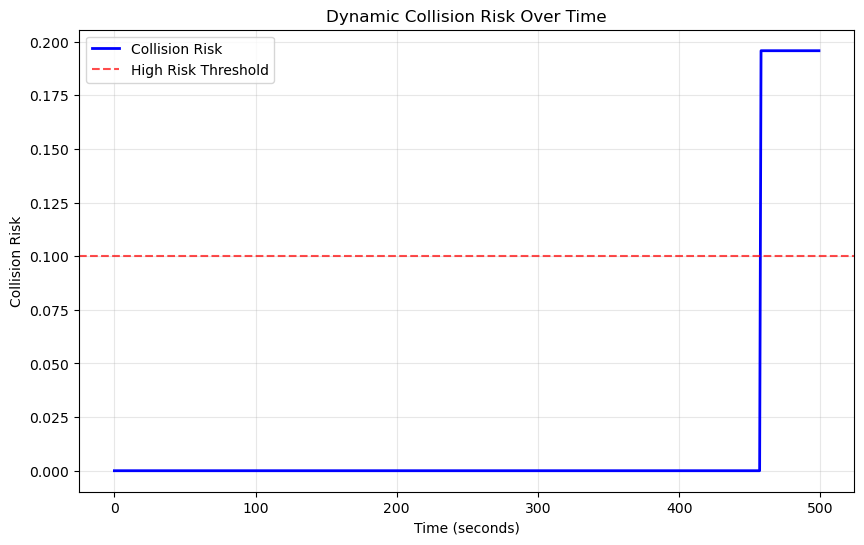


Maximum risk: 0.1958 at t=458s


In [37]:
# Dynamic Risk Calculation - Real-time collision risk assessment
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Optional

def get_aircraft_position_at_time(path: List[str], nodePositions: Dict, segment_times: List[float], t: float) -> Tuple[str, float]:
    """
    Get the current node and progress within that node for an aircraft at time t.
    Returns (current_node, progress_fraction) where progress_fraction is 0.0 at start of node, 1.0 at end.
    """
    if t <= 0:
        return path[0], 0.0
    
    cumulative_time = 0.0
    for i, segment_time in enumerate(segment_times):
        if t <= cumulative_time + segment_time:
            # Aircraft is in segment i -> i+1
            progress = (t - cumulative_time) / segment_time
            return path[i], progress
        cumulative_time += segment_time
    
    # Aircraft has completed the path
    return path[-1], 1.0

def calculate_dynamic_risk_at_time(
    path1: List[str], segment_times1: List[float],  # KLM 4805
    path2: List[str], segment_times2: List[float],  # Clipper 1736
    nodePositions: Dict,
    link_dict: Dict[Tuple[str,str], Tuple[float,float,float]],
    rc: float,
    epsilon: float,
    t: float,
    time_offset: float = 0.0  # Clipper starts at time_offset
) -> Dict:
    """
    Calculate dynamic collision risk at time t, considering aircraft positions.
    
    Args:
        path1, segment_times1: KLM 4805 path and timing
        path2, segment_times2: Clipper 1736 path and timing  
        nodePositions: Node coordinates
        link_dict: Link parameters
        rc: Collision radius
        epsilon: Time window
        t: Current simulation time
        time_offset: When Clipper starts (0 = same time as KLM)
    
    Returns:
        Dictionary with risk information
    """
    
    # Get current positions of both aircraft
    klm_node, klm_progress = get_aircraft_position_at_time(path1, nodePositions, segment_times1, t)
    clipper_time = max(0, t - time_offset)  # Clipper starts later
    clipper_node, clipper_progress = get_aircraft_position_at_time(path2, nodePositions, segment_times2, clipper_time)
    
    # Check if both aircraft are at the same node
    if klm_node == clipper_node:
        # Both aircraft are at the same node - high collision risk
        risk_type = "SAME_NODE"
        risk_level = "CRITICAL"
        
        # Calculate risk based on their progress within the node
        # If both are at the same progress, risk is highest
        progress_diff = abs(klm_progress - clipper_progress)
        proximity_factor = 1.0 - progress_diff  # 1.0 when at same progress, 0.0 when at opposite ends
        
        # Use the existing risk calculation functions for this node
        try:
            links1 = get_cumulative_links(path1, klm_node, link_dict)
            links2 = get_cumulative_links(path2, clipper_node, link_dict)
            
            if links1 and links2:
                f0, (mu1_star, s1_star), (mu2_star, s2_star) = node_overlap_density_fdelta0(links1, links2)
                Ppn = pn_probability_small_window(f0, epsilon)
                mu_v1_in, s_v1_in = links1[-1][1], links1[-1][2]
                mu_v2_in, s_v2_in = links2[-1][1], links2[-1][2]
                Pfw = fw_collision_probability(f0, rc, mu_v1_in, s_v1_in, mu_v2_in, s_v2_in, how="average")
                
                # Adjust risk based on proximity within the node
                adjusted_Ppn = Ppn * proximity_factor
                adjusted_Pfw = Pfw * proximity_factor
            else:
                adjusted_Ppn = 0.0
                adjusted_Pfw = 0.0
        except:
            adjusted_Ppn = 1.0  # Maximum risk if calculation fails
            adjusted_Pfw = 1.0
            
    else:
        # Aircraft are at different nodes
        risk_type = "DIFFERENT_NODES"
        risk_level = "LOW"
        adjusted_Ppn = 0.0
        adjusted_Pfw = 0.0
        proximity_factor = 0.0
    
    return {
        "time": t,
        "klm_node": klm_node,
        "klm_progress": klm_progress,
        "clipper_node": clipper_node, 
        "clipper_progress": clipper_progress,
        "risk_type": risk_type,
        "risk_level": risk_level,
        "proximity_factor": proximity_factor,
        "P_PN_epsilon": adjusted_Ppn,
        "P_FW": adjusted_Pfw,
        "collision_risk": max(adjusted_Ppn, adjusted_Pfw)
    }

def simulate_dynamic_risk(
    path1: List[str], segment_times1: List[float],  # KLM 4805
    path2: List[str], segment_times2: List[float],  # Clipper 1736
    nodePositions: Dict,
    link_dict: Dict[Tuple[str,str], Tuple[float,float,float]],
    rc: float = 0.075,
    epsilon: float = 1/60.0,
    time_offset: float = 0.0,
    time_step: float = 1.0,
    max_time: float = 500.0
) -> List[Dict]:
    """
    Simulate dynamic risk over time for both aircraft.
    """
    risk_history = []
    
    for t in np.arange(0, max_time, time_step):
        risk_data = calculate_dynamic_risk_at_time(
            path1, segment_times1, path2, segment_times2,
            nodePositions, link_dict, rc, epsilon, t, time_offset
        )
        risk_history.append(risk_data)
    
    return risk_history

# Test the dynamic risk calculation
print("=== DYNAMIC RISK CALCULATION ===")
print("Simulating collision risk over time...")

# Use the paths and timing from the case study
path_klm = ['Rwy_12_001', 'Rwy_12_002', 'Rwy_12_003', 'Rwy_12_004', 'Rwy_12_005', 'Rwy_12_006', 'Rwy_12_005']
path_clipper = ['Txy_C0_001', 'Txy_C0_002', 'Rwy_12_001', 'Rwy_12_002', 'Rwy_12_003', 'Rwy_12_004', 'Rwy_12_005']

# Use the timing from the case study
klm_segment_times = [76, 53, 49, 35, 190, 54]  # Total: 457 seconds
clipper_segment_times = [121, 57, 96, 67, 62, 54]  # Total: 457 seconds

# Simulate with 1-second time steps
risk_history = simulate_dynamic_risk(
    path_klm, klm_segment_times,
    path_clipper, clipper_segment_times,
    positions,  # Use the positions from the path generation
    link_dict,
    rc=0.075,
    epsilon=1/60.0,
    time_offset=0.0,  # Both start at same time
    time_step=1.0,
    max_time=500.0
)

# Find critical moments
critical_moments = [r for r in risk_history if r["risk_level"] == "CRITICAL"]

print(f"\nFound {len(critical_moments)} critical moments:")
for moment in critical_moments[:10]:  # Show first 10
    print(f"t={moment['time']:3.0f}s: KLM at {moment['klm_node']} ({moment['klm_progress']:.2f}), "
          f"Clipper at {moment['clipper_node']} ({moment['clipper_progress']:.2f}), "
          f"Risk={moment['collision_risk']:.4f}")

# Plot risk over time
times = [r["time"] for r in risk_history]
risks = [r["collision_risk"] for r in risk_history]

plt.figure(figsize=(10, 6))
plt.plot(times, risks, 'b-', linewidth=2, label='Collision Risk')
plt.axhline(y=0.1, color='r', linestyle='--', alpha=0.7, label='High Risk Threshold')
plt.xlabel('Time (seconds)')
plt.ylabel('Collision Risk')
plt.title('Dynamic Collision Risk Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nMaximum risk: {max(risks):.4f} at t={times[risks.index(max(risks))]:.0f}s")


=== CORRECTED FW-BASED DYNAMIC RISK CALCULATION ===
Calculating travel time distributions to intersection nodes...
Found intersection nodes: ['Rwy_12_005', 'Rwy_12_001', 'Rwy_12_003', 'Rwy_12_002', 'Rwy_12_004']

Analyzing collision risk at node: Rwy_12_005
  KLM links to Rwy_12_005: 4 segments
  Clipper links to Rwy_12_005: 6 segments
  KLM travel time: mean=0.67s, var=0.00s², lognormal params: μ=-0.404, σ=0.088
  Clipper travel time: mean=0.73s, var=0.00s², lognormal params: μ=-0.324, σ=0.082
  f_Δ(0) = 3.809655
  P_PN^(ε) = 0.126988
  P_FW = 0.195774

Analyzing collision risk at node: Rwy_12_001

Analyzing collision risk at node: Rwy_12_003
  KLM links to Rwy_12_003: 2 segments
  Clipper links to Rwy_12_003: 4 segments
  KLM travel time: mean=0.43s, var=0.00s², lognormal params: μ=-0.860, σ=0.119
  Clipper travel time: mean=0.48s, var=0.00s², lognormal params: μ=-0.735, σ=0.107
  f_Δ(0) = 4.080901
  P_PN^(ε) = 0.136030
  P_FW = 0.209713

Analyzing collision risk at node: Rwy_12_002


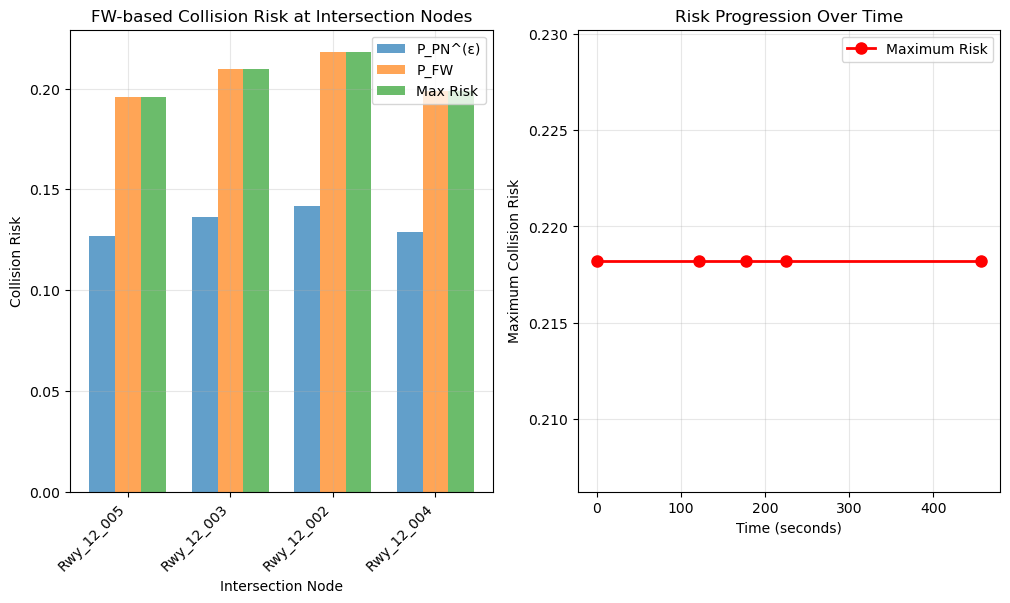


=== SUMMARY ===
Highest collision risk: 0.218217 at node Rwy_12_002
Number of intersection nodes: 4


In [38]:
# Corrected FW-based Dynamic Risk Calculation
# The FW approach calculates travel time distributions to potential collision points
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Optional

def calculate_fw_risk_at_intersection_nodes(
    path1: List[str],  # KLM 4805 path
    path2: List[str],  # Clipper 1736 path
    link_dict: Dict[Tuple[str,str], Tuple[float,float,float]],
    rc: float = 0.075,
    epsilon: float = 1/60.0
) -> List[Dict]:
    """
    Calculate FW-based collision risk at intersection nodes.
    This considers the probability distributions of travel times for both aircraft
    to reach each potential collision point (intersection node).
    """
    
    # Find all intersection nodes (nodes that appear in both paths)
    intersection_nodes = list(set(path1) & set(path2))
    print(f"Found intersection nodes: {intersection_nodes}")
    
    risk_results = []
    
    for node in intersection_nodes:
        print(f"\nAnalyzing collision risk at node: {node}")
        
        # Get cumulative links for both aircraft up to this intersection node
        klm_links = get_cumulative_links(path1, node, link_dict)
        clipper_links = get_cumulative_links(path2, node, link_dict)
        
        if not klm_links or not clipper_links:
            print(f"  Warning: Could not get links for node {node}")
            continue
            
        print(f"  KLM links to {node}: {len(klm_links)} segments")
        print(f"  Clipper links to {node}: {len(clipper_links)} segments")
        
        # Calculate FW parameters for both aircraft's travel time distributions
        try:
            # Calculate moments for KLM's travel time to this node
            M1, V1 = compute_total_moments_links(klm_links)
            mu1_star, s1_star = fenton_wilkinson_params(M1, V1)
            
            # Calculate moments for Clipper's travel time to this node  
            M2, V2 = compute_total_moments_links(clipper_links)
            mu2_star, s2_star = fenton_wilkinson_params(M2, V2)
            
            print(f"  KLM travel time: mean={M1:.2f}s, var={V1:.2f}s², lognormal params: μ={mu1_star:.3f}, σ={s1_star:.3f}")
            print(f"  Clipper travel time: mean={M2:.2f}s, var={V2:.2f}s², lognormal params: μ={mu2_star:.3f}, σ={s2_star:.3f}")
            
            # Calculate f_Δ(0) - the probability density of simultaneous arrival
            f_delta0 = f_delta_zero_lognormals(mu1_star, s1_star, mu2_star, s2_star)
            print(f"  f_Δ(0) = {f_delta0:.6f}")
            
            # Calculate P_PN^(ε) - near-miss probability in small time window
            Ppn = pn_probability_small_window(f_delta0, epsilon)
            print(f"  P_PN^(ε) = {Ppn:.6f}")
            
            # Calculate P_FW - Fenton-Wilkinson collision probability
            # Use the incoming link speed parameters for the "local" speed
            mu_v1_in, s_v1_in = klm_links[-1][1], klm_links[-1][2]
            mu_v2_in, s_v2_in = clipper_links[-1][1], clipper_links[-1][2]
            Pfw = fw_collision_probability(f_delta0, rc, mu_v1_in, s_v1_in, mu_v2_in, s_v2_in, how="average")
            print(f"  P_FW = {Pfw:.6f}")
            
            # Store results
            result = {
                "node": node,
                "klm_travel_time_mean": M1,
                "klm_travel_time_var": V1,
                "klm_mu_star": mu1_star,
                "klm_sigma_star": s1_star,
                "clipper_travel_time_mean": M2,
                "clipper_travel_time_var": V2,
                "clipper_mu_star": mu2_star,
                "clipper_sigma_star": s2_star,
                "f_delta0": f_delta0,
                "P_PN_epsilon": Ppn,
                "P_FW": Pfw,
                "collision_risk": max(Ppn, Pfw)
            }
            
            risk_results.append(result)
            
        except Exception as e:
            print(f"  Error calculating risk for node {node}: {e}")
            continue
    
    return risk_results

def analyze_temporal_risk_progression(
    path1: List[str],  # KLM 4805 path
    path2: List[str],  # Clipper 1736 path
    link_dict: Dict[Tuple[str,str], Tuple[float,float,float]],
    rc: float = 0.075,
    epsilon: float = 1/60.0,
    time_points: List[float] = None
) -> List[Dict]:
    """
    Analyze how collision risk changes over time as aircraft progress through their paths.
    This shows the dynamic nature of risk as aircraft approach intersection points.
    """
    
    if time_points is None:
        # Define time points based on the four critical moments
        time_points = [0, 121, 178, 225, 457]  # Based on segment times
    
    intersection_nodes = list(set(path1) & set(path2))
    risk_progression = []
    
    for t in time_points:
        print(f"\nAnalyzing risk at time t={t}s")
        
        # Determine which nodes each aircraft has reached by time t
        # This is a simplified approach - in practice, you'd use the actual timing data
        klm_position = get_aircraft_position_at_time_simple(path1, t)
        clipper_position = get_aircraft_position_at_time_simple(path2, t)
        
        print(f"  KLM position: {klm_position}")
        print(f"  Clipper position: {clipper_position}")
        
        # Calculate risk for each intersection node that could be reached
        time_risk = {"time": t, "klm_position": klm_position, "clipper_position": clipper_position}
        
        for node in intersection_nodes:
            try:
                # Get links up to this node
                klm_links = get_cumulative_links(path1, node, link_dict)
                clipper_links = get_cumulative_links(path2, node, link_dict)
                
                if klm_links and clipper_links:
                    # Calculate FW risk for this node
                    M1, V1 = compute_total_moments_links(klm_links)
                    M2, V2 = compute_total_moments_links(clipper_links)
                    mu1_star, s1_star = fenton_wilkinson_params(M1, V1)
                    mu2_star, s2_star = fenton_wilkinson_params(M2, V2)
                    
                    f_delta0 = f_delta_zero_lognormals(mu1_star, s1_star, mu2_star, s2_star)
                    Ppn = pn_probability_small_window(f_delta0, epsilon)
                    mu_v1_in, s_v1_in = klm_links[-1][1], klm_links[-1][2]
                    mu_v2_in, s_v2_in = clipper_links[-1][1], clipper_links[-1][2]
                    Pfw = fw_collision_probability(f_delta0, rc, mu_v1_in, s_v1_in, mu_v2_in, s_v2_in, how="average")
                    
                    time_risk[f"risk_{node}"] = {
                        "f_delta0": f_delta0,
                        "P_PN_epsilon": Ppn,
                        "P_FW": Pfw,
                        "collision_risk": max(Ppn, Pfw)
                    }
                else:
                    time_risk[f"risk_{node}"] = {"collision_risk": 0.0}
                    
            except Exception as e:
                print(f"    Error calculating risk for node {node} at time {t}: {e}")
                time_risk[f"risk_{node}"] = {"collision_risk": 0.0}
        
        risk_progression.append(time_risk)
    
    return risk_progression

def get_aircraft_position_at_time_simple(path: List[str], t: float) -> str:
    """
    Simplified function to determine aircraft position at time t.
    This is a placeholder - in practice, you'd use the actual segment timing data.
    """
    # This is a simplified approach - you'd need to use actual timing data
    if t < 50:
        return path[0]
    elif t < 100:
        return path[1] if len(path) > 1 else path[0]
    elif t < 150:
        return path[2] if len(path) > 2 else path[-1]
    elif t < 200:
        return path[3] if len(path) > 3 else path[-1]
    elif t < 300:
        return path[4] if len(path) > 4 else path[-1]
    else:
        return path[-1]

# Run the corrected FW-based risk analysis
print("=== CORRECTED FW-BASED DYNAMIC RISK CALCULATION ===")
print("Calculating travel time distributions to intersection nodes...")

# Use the paths from the case study
path_klm = ['Rwy_12_001', 'Rwy_12_002', 'Rwy_12_003', 'Rwy_12_004', 'Rwy_12_005', 'Rwy_12_006', 'Rwy_12_005']
path_clipper = ['Txy_C0_001', 'Txy_C0_002', 'Rwy_12_001', 'Rwy_12_002', 'Rwy_12_003', 'Rwy_12_004', 'Rwy_12_005']

# Calculate FW risk at intersection nodes
intersection_risks = calculate_fw_risk_at_intersection_nodes(path_klm, path_clipper, link_dict)

print("\n=== INTERSECTION NODE RISK ANALYSIS ===")
for result in intersection_risks:
    print(f"\nNode: {result['node']}")
    print(f"  KLM travel time: {result['klm_travel_time_mean']:.2f}s ± {np.sqrt(result['klm_travel_time_var']):.2f}s")
    print(f"  Clipper travel time: {result['clipper_travel_time_mean']:.2f}s ± {np.sqrt(result['clipper_travel_time_var']):.2f}s")
    print(f"  f_Δ(0): {result['f_delta0']:.6f}")
    print(f"  P_PN^(ε): {result['P_PN_epsilon']:.6f}")
    print(f"  P_FW: {result['P_FW']:.6f}")
    print(f"  Collision Risk: {result['collision_risk']:.6f}")

# Analyze temporal risk progression
print("\n=== TEMPORAL RISK PROGRESSION ===")
risk_progression = analyze_temporal_risk_progression(path_klm, path_clipper, link_dict)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Risk at intersection nodes
if intersection_risks:
    nodes = [r['node'] for r in intersection_risks]
    risks = [r['collision_risk'] for r in intersection_risks]
    pn_risks = [r['P_PN_epsilon'] for r in intersection_risks]
    fw_risks = [r['P_FW'] for r in intersection_risks]
    
    x = np.arange(len(nodes))
    width = 0.25
    
    bars1 = ax1.bar(x - width, pn_risks, width, label='P_PN^(ε)', alpha=0.7)
    bars2 = ax1.bar(x, fw_risks, width, label='P_FW', alpha=0.7)
    bars3 = ax1.bar(x + width, risks, width, label='Max Risk', alpha=0.7)
    
    ax1.set_xlabel('Intersection Node')
    ax1.set_ylabel('Collision Risk')
    ax1.set_title('FW-based Collision Risk at Intersection Nodes')
    ax1.set_xticks(x)
    ax1.set_xticklabels(nodes, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

# Plot 2: Risk progression over time
if risk_progression:
    times = [r['time'] for r in risk_progression]
    max_risks = []
    
    for r in risk_progression:
        node_risks = [v['collision_risk'] for k, v in r.items() if k.startswith('risk_')]
        max_risks.append(max(node_risks) if node_risks else 0.0)
    
    ax2.plot(times, max_risks, 'ro-', linewidth=2, markersize=8, label='Maximum Risk')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Maximum Collision Risk')
    ax2.set_title('Risk Progression Over Time')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.show()

print(f"\n=== SUMMARY ===")
if intersection_risks:
    max_risk = max(r['collision_risk'] for r in intersection_risks)
    max_risk_node = max(intersection_risks, key=lambda x: x['collision_risk'])['node']
    print(f"Highest collision risk: {max_risk:.6f} at node {max_risk_node}")
    print(f"Number of intersection nodes: {len(intersection_risks)}")
else:
    print("No intersection nodes found or risk calculation failed.")


In [39]:
import math

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate the great-circle distance (in kilometers) between two points on Earth."""
    R = 6371  # Earth radius in kilometers
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)
    a = math.sin(delta_phi/2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda/2)**2
    distance = 2 * R * math.asin(math.sqrt(a))
    return distance

# Node coordinates from GCXO_Nodes_Def.csv
nodes = {
    'Rwy_12_001': (28.487889, -16.357273),
    'Rwy_12_002': (28.485553, -16.350255),
    'Rwy_12_003': (28.483932, -16.345360),
    'Rwy_12_004': (28.482443, -16.340874),
    'Rwy_12_005': (28.481667, -16.338548),
    'Rwy_12_006': (28.477426, -16.325730),
    'Txy_C0_001': (28.488761, -16.356464),
    'Txy_C0_002': (28.488325, -16.357476)
}

# Calculate distances for each link
links = [
    ('Txy_C0_001', 'Txy_C0_002'),
    ('Txy_C0_002', 'Rwy_12_001'),
    ('Rwy_12_001', 'Rwy_12_002'),
    ('Rwy_12_002', 'Rwy_12_003'),
    ('Rwy_12_003', 'Rwy_12_004'),
    ('Rwy_12_004', 'Rwy_12_005'),
    ('Rwy_12_005', 'Rwy_12_006'),
    ('Rwy_12_006', 'Rwy_12_005')
]

print("Actual link distances in kilometers:")
for link in links:
    node1, node2 = link
    lat1, lon1 = nodes[node1]
    lat2, lon2 = nodes[node2]
    distance = haversine_distance(lat1, lon1, lat2, lon2)
    print(f"  {node1} -> {node2}: {distance:.4f} km")

Actual link distances in kilometers:
  Txy_C0_001 -> Txy_C0_002: 0.1101 km
  Txy_C0_002 -> Rwy_12_001: 0.0524 km
  Rwy_12_001 -> Rwy_12_002: 0.7334 km
  Rwy_12_002 -> Rwy_12_003: 0.5112 km
  Rwy_12_003 -> Rwy_12_004: 0.4687 km
  Rwy_12_004 -> Rwy_12_005: 0.2432 km
  Rwy_12_005 -> Rwy_12_006: 1.3386 km
  Rwy_12_006 -> Rwy_12_005: 1.3386 km
